In [7]:
# imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# training device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
# loading CIFAR10 dataset and

# tranform for normalizing dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3)
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# creating DataLoader for training loop (also this makes batches)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [13]:
# for checking shape of input and label
data_iter = iter(train_loader)
images, labels = next(data_iter)

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 32, 32])
torch.Size([64])


In [19]:
# PrunableLinear layer class
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):

        # to inherit properties of nn.Module
        super(PrunableLinear, self).__init__()

        # weight matrix initialization
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.02)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # gate scores matrix
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):

        # to compress scores between 0 and 1
        gates = torch.sigmoid(self.gate_scores)

        # weight multiplication
        pruned_weights = self.weight * gates

        # F.linear does weight*input + bias
        return F.linear(x, pruned_weights, self.bias)

In [20]:
# Model Class
class PrunableNet(nn.Module):
    def __init__(self):
        super(PrunableNet, self).__init__()

        # defining the layer architecture

        # (batchsize,3,32,32) is the cifar10 input shape
        self.fc1 = PrunableLinear(32*32*3, 1024)
        self.fc2 = PrunableLinear(1024, 512)
        self.fc3 = PrunableLinear(512, 256)
        self.fc4 = PrunableLinear(256, 128)
        self.fc5 = PrunableLinear(128, 10)

    def forward(self, x):
        # to convert (batchsize,3,32,32) into (batchsize,3*32*32)
        x = x.view(x.size(0), -1)

        # using relu activation
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [17]:
# to compute L1 sparsity loss
def compute_sparsity_loss(model):
  loss = 0.0
  for module in model.modules():
  # iterating in model layers
    if isinstance(module, PrunableLinear):
      gates = torch.sigmoid(module.gate_scores)
      loss += gates.sum()   # summing all the gates (only 1 scores will contribute)
  return loss

# to evaluate model for test set
def evaluate(model, loader):

  # enabling eval model
  model.eval()
  correct, total = 0, 0

  # so that no gradients are calculated
  with torch.no_grad():
    for images, labels in loader:
      images, labels = images.to(device), labels.to(device)

      outputs = model(images) # shape : (batchsize, 10)
      _, predicted = outputs.max(1) # finding maximum index

      correct += predicted.eq(labels).sum().item() # checking predicted==labels (true=1, false=0)
      total += labels.size(0) # batchsize

  # returning percentage accuracy
  return 100. * correct / total


# to compute final sparsity levels of model after training
def compute_sparsity(model, threshold=1e-2):
    total, pruned = 0, 0

    for module in model.modules():
        # iterating in model layers
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            # number of elements in gate matrix of that layer
            total += gates.size(0) * gates.size(1)

            # number of scores that are less than threshold (pruned)
            pruned += (gates < threshold).sum().item()

    return pruned, total, pruned / total


In [21]:
# trying with multiple lambda values
lambda_values = [1e-4, 1e-3, 1e-5, 8e-5, 8e-3]

# models and results list
models = []
results = []

epochs = 30

# for inital epochs we use loss as only classification loss so that model first learns its weights, then after that it starts pruning gate scores
# i.e. (we add sparsity loss after epoch 5)
initial_epochs = 5

for lam in lambda_values:
    print(f"\nTraining with lambda = {lam}")

    # defining model instance
    model = PrunableNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()

        correct, total, total_loss = 0, 0, 0

        # tqdm for visualising epoch
        loop = tqdm(train_loader, desc=f"λ={lam} Epoch {epoch+1}", leave=False)

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            cls_loss = criterion(outputs, labels)

            sparsity_loss = compute_sparsity_loss(model) # this will be added in loss only if epoch > inital_epochs (epoch>5)

            # defining loss
            if epoch < initial_epochs:
                loss = cls_loss
            else:
                loss = cls_loss + lam * sparsity_loss

            total_loss += loss.item()

            # setting all gradients to zero
            optimizer.zero_grad()

            # gradients calcuations
            loss.backward()

            #updating weights, gates and biases
            optimizer.step()

            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            acc = 100. * correct / total

            loop.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{acc:.2f}%"})

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}, Train Acc: {acc:.2f}%, Loss: {avg_loss:.4f}")

    # testing on that model
    test_acc = evaluate(model, test_loader)

    pruned, total_params, ratio = compute_sparsity(model)
    sparsity = ratio * 100

    print(f"Lambda={lam}, Test Acc={test_acc:.2f}%, Sparsity={sparsity:.2f}%")

    models.append(model)
    results.append((lam, test_acc, sparsity))



Training with lambda = 0.0001


Epoch 1, Train Acc: 39.23%


Epoch 2, Train Acc: 49.32%


Epoch 3, Train Acc: 54.16%


Epoch 4, Train Acc: 58.22%


...

Epoch 26, Train Acc: 46.82%


Epoch 27, Train Acc: 47.10%


Epoch 28, Train Acc: 47.24%


Epoch 29, Train Acc: 47.43%


Epoch 30, Train Acc: 47.65%
Lambda=0.008 → Test Acc=46.58%, Sparsity=99.98%


In [22]:
# comparing results for all models
print("\nFinal Results Table:\n")
print("Lambda\t\tTest Acc (%)\t\tSparsity (%)")

for lam, acc, sp in results:
    print(f"{lam}\t\t{acc:.2f}\t\t{sp:.2f}")


Final Results Table:

Lambda		Test Acc (%)		Sparsity (%)
0.0001		56.06		88.45
0.001		55.65		99.76
1e-05		56.33		48.44
8e-05		56.39		86.44
0.008		46.58		99.98


In [23]:
# selecting best test accuracy model for gate distrbution
best_index = max(range(len(results)), key=lambda i: results[i][1])
best_model = models[best_index]

print(f"\nBest Lambda: {results[best_index][0]}")


Best Lambda: 8e-05


In [24]:
# below cell's result shows spike at 0 that means weights are successfully being pruned

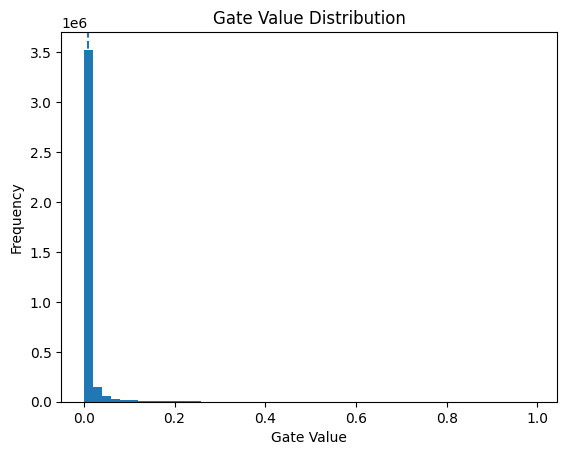

In [25]:
# gate distributtion plot
all_gates = []

for module in best_model.modules():
    # iterating model layers
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(module.gate_scores) # shape : (out_features, in_features)
        all_gates.append(gates.detach().cpu().view(-1)) # .cpu because matplotlib only support elements on cpu

all_gates = torch.cat(all_gates).numpy()

plt.figure()
plt.hist(all_gates, bins=50)
plt.axvline(x=0.01, linestyle='--')
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()